# Titanic Survival Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier


In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

df.columns

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [6]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [7]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


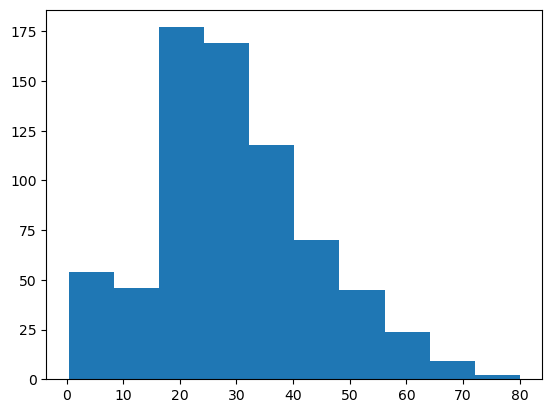

In [8]:
plt.hist(df["Age"].dropna())
plt.show()


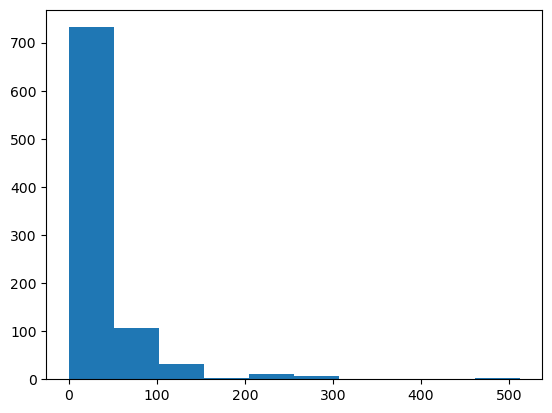

In [9]:
plt.hist(df["Fare"])
plt.show()

In [11]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.drop("Cabin", axis=1, inplace=True)

In [13]:
encoder = LabelEncoder()

df["Sex"] = encoder.fit_transform(df["Sex"])

df["Embarked"] = encoder.fit_transform(df["Embarked"])

In [14]:
df.drop(["Name","Ticket","PassengerId"], axis=1, inplace=True)


In [15]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [16]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = DecisionTreeClassifier()

model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
prediction = model.predict(X_test)


In [19]:
accuracy_score(y_test,prediction)

0.7877094972067039

In [20]:
confusion_matrix(y_test,prediction)

array([[83, 22],
       [16, 58]])

In [21]:
classification_report(y_test,prediction)

'              precision    recall  f1-score   support\n\n           0       0.84      0.79      0.81       105\n           1       0.72      0.78      0.75        74\n\n    accuracy                           0.79       179\n   macro avg       0.78      0.79      0.78       179\nweighted avg       0.79      0.79      0.79       179\n'

# Comparing Multiple Models

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

In [24]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train, y_train)

    # Predict
    prediction = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, prediction)

    # Store Result
    results.append([name, accuracy])

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.8101
Decision Tree: 0.7821
Random Forest: 0.8212
KNN: 0.7207
SVM: 0.6592
Naive Bayes: 0.7765


In [25]:
comparison = pd.DataFrame(results, columns=["Model", "Accuracy"])

comparison


,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.782123
2,Random Forest,0.821229
3,KNN,0.720670
4,SVM,0.659218
5,Naive Bayes,0.776536


In [26]:
comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
2,Random Forest,0.821229
0,Logistic Regression,0.810056
1,Decision Tree,0.782123
5,Naive Bayes,0.776536
3,KNN,0.720670
4,SVM,0.659218


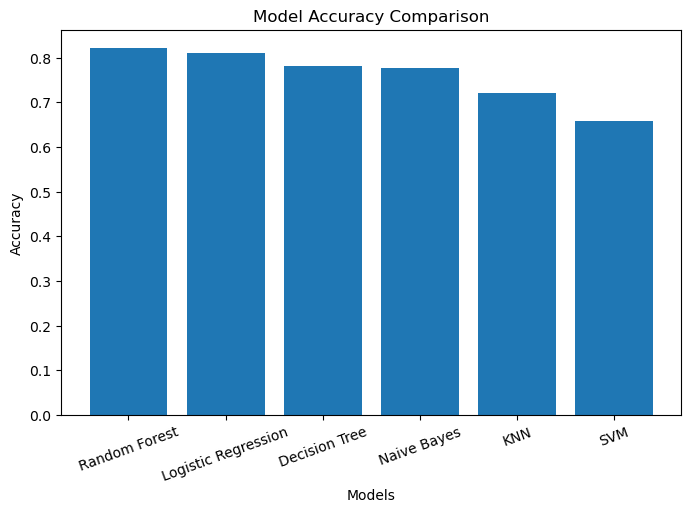

In [27]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [28]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    results.append([name, accuracy, precision, recall, f1])

comparison = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.821229,0.808824,0.743243,0.774648
0,Logistic Regression,0.810056,0.785714,0.743243,0.763889
1,Decision Tree,0.782123,0.721519,0.770270,0.745098
5,Naive Bayes,0.776536,0.712500,0.770270,0.740260
3,KNN,0.720670,0.714286,0.540541,0.615385
4,SVM,0.659218,0.760000,0.256757,0.383838


In [30]:
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [32]:
prediction = model.predict(X_test)


In [33]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

In [34]:
prediction_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": prediction
})

prediction_df.head(10)


,Actual,Predicted
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


In [39]:
for name, model in models.items():
    prediction = model.predict(X_test)

In [40]:
best_model = RandomForestClassifier(random_state=42)

best_model.fit(X_train, y_train)

prediction = best_model.predict(X_test)

In [41]:
result = X_test.copy()

result["Actual"] = y_test

result["Predicted"] = prediction

result.head(10)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted
709,3,1,28.0,1,1,15.2458,0,1,0
439,2,1,31.0,0,0,10.5000,2,0,0
840,3,1,20.0,0,0,7.9250,2,0,0
720,2,0,6.0,0,1,33.0000,2,1,1
39,3,0,14.0,1,0,11.2417,0,1,0
290,1,0,26.0,0,0,78.8500,2,1,1
300,3,0,28.0,0,0,7.7500,1,1,1
333,3,1,16.0,2,0,18.0000,2,0,0
208,3,0,16.0,0,0,7.7500,1,1,1
136,1,0,19.0,0,2,26.2833,2,1,1


# Prediction Table

In [42]:
result = X_test.copy()

result["Actual"] = y_test.values
result["Predicted"] = prediction

result["Status"] = np.where(
    result["Actual"] == result["Predicted"],
    "✅ Correct",
    "❌ Incorrect"
)

result.head(20)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted,Status
709,3,1,28.0,1,1,15.2458,0,1,0,❌ Incorrect
439,2,1,31.0,0,0,10.5000,2,0,0,✅ Correct
840,3,1,20.0,0,0,7.9250,2,0,0,✅ Correct
720,2,0,6.0,0,1,33.0000,2,1,1,✅ Correct
39,3,0,14.0,1,0,11.2417,0,1,0,❌ Incorrect
290,1,0,26.0,0,0,78.8500,2,1,1,✅ Correct
300,3,0,28.0,0,0,7.7500,1,1,1,✅ Correct
333,3,1,16.0,2,0,18.0000,2,0,0,✅ Correct
208,3,0,16.0,0,0,7.7500,1,1,1,✅ Correct
136,1,0,19.0,0,2,26.2833,2,1,1,✅ Correct


In [43]:
result["Actual"] = result["Actual"].map({
    0:"Did Not Survive",
    1:"Survived"
})

result["Predicted"] = result["Predicted"].map({
    0:"Did Not Survive",
    1:"Survived"
})

result.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted,Status
709,3,1,28.0,1,1,15.2458,0,Survived,Did Not Survive,❌ Incorrect
439,2,1,31.0,0,0,10.5000,2,Did Not Survive,Did Not Survive,✅ Correct
840,3,1,20.0,0,0,7.9250,2,Did Not Survive,Did Not Survive,✅ Correct
720,2,0,6.0,0,1,33.0000,2,Survived,Survived,✅ Correct
39,3,0,14.0,1,0,11.2417,0,Survived,Did Not Survive,❌ Incorrect
290,1,0,26.0,0,0,78.8500,2,Survived,Survived,✅ Correct
300,3,0,28.0,0,0,7.7500,1,Survived,Survived,✅ Correct
333,3,1,16.0,2,0,18.0000,2,Did Not Survive,Did Not Survive,✅ Correct
208,3,0,16.0,0,0,7.7500,1,Survived,Survived,✅ Correct
136,1,0,19.0,0,2,26.2833,2,Survived,Survived,✅ Correct


In [44]:
def color_status(val):
    if val == "✅ Correct":
        return "background-color: lightgreen"
    else:
        return "background-color: salmon"

result.style.applymap(color_status, subset=["Status"])

C:\Users\soura\AppData\Local\Temp\ipykernel_9536\327635466.py:7: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  result.style.applymap(color_status, subset=["Status"])


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted,Status
709,3,1,28.000000,1,1,15.245800,0,Survived,Did Not Survive,❌ Incorrect
439,2,1,31.000000,0,0,10.500000,2,Did Not Survive,Did Not Survive,✅ Correct
840,3,1,20.000000,0,0,7.925000,2,Did Not Survive,Did Not Survive,✅ Correct
720,2,0,6.000000,0,1,33.000000,2,Survived,Survived,✅ Correct
39,3,0,14.000000,1,0,11.241700,0,Survived,Did Not Survive,❌ Incorrect
290,1,0,26.000000,0,0,78.850000,2,Survived,Survived,✅ Correct
300,3,0,28.000000,0,0,7.750000,1,Survived,Survived,✅ Correct
333,3,1,16.000000,2,0,18.000000,2,Did Not Survive,Did Not Survive,✅ Correct
208,3,0,16.000000,0,0,7.750000,1,Survived,Survived,✅ Correct
136,1,0,19.000000,0,2,26.283300,2,Survived,Survived,✅ Correct


In [45]:
prob = best_model.predict_proba(X_test)

prob[:5]

array([[0.67      , 0.33      ],
       [0.97      , 0.03      ],
       [0.91583333, 0.08416667],
       [0.02      , 0.98      ],
       [0.63      , 0.37      ]])

In [46]:
result["Confidence"] = np.max(prob, axis=1)

result.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted,Status,Confidence
709,3,1,28.0,1,1,15.2458,0,Survived,Did Not Survive,❌ Incorrect,0.670000
439,2,1,31.0,0,0,10.5000,2,Did Not Survive,Did Not Survive,✅ Correct,0.970000
840,3,1,20.0,0,0,7.9250,2,Did Not Survive,Did Not Survive,✅ Correct,0.915833
720,2,0,6.0,0,1,33.0000,2,Survived,Survived,✅ Correct,0.980000
39,3,0,14.0,1,0,11.2417,0,Survived,Did Not Survive,❌ Incorrect,0.630000


## Confusion matrix

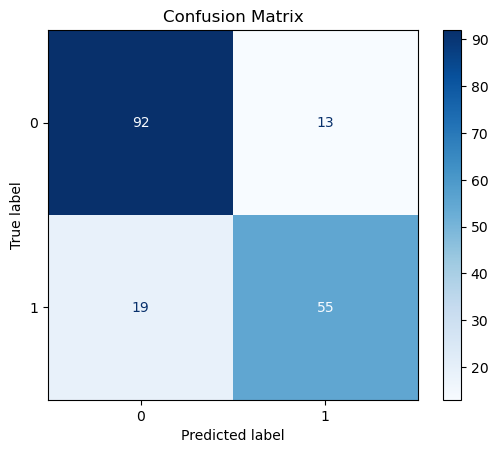

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

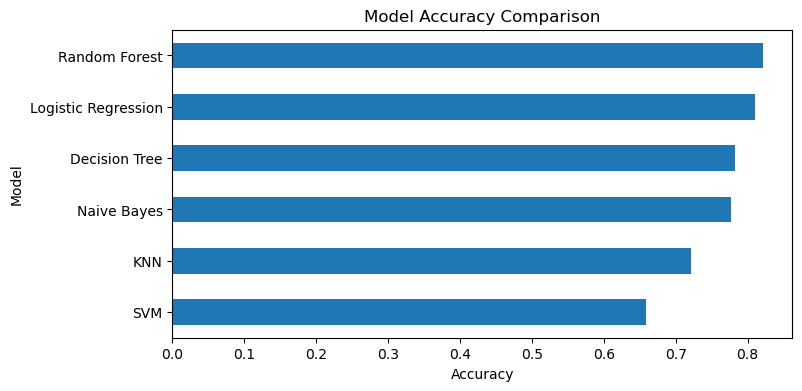

In [48]:
comparison.sort_values("Accuracy").plot(
    x="Model",
    y="Accuracy",
    kind="barh",
    legend=False,
    figsize=(8,4)
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.show()

In [49]:
sample = result.sample(10, random_state=42)

sample


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Actual,Predicted,Status,Confidence
357,2,0,38.0,0,0,13.0000,2,Did Not Survive,Survived,❌ Incorrect,0.980000
621,1,1,42.0,1,0,52.5542,2,Survived,Did Not Survive,❌ Incorrect,0.730000
772,2,0,57.0,0,0,10.5000,2,Did Not Survive,Survived,❌ Incorrect,0.960000
527,1,1,28.0,0,0,221.7792,2,Did Not Survive,Did Not Survive,✅ Correct,0.762500
767,3,0,30.5,0,0,7.7500,1,Did Not Survive,Survived,❌ Incorrect,0.731591
110,1,1,47.0,0,0,52.0000,2,Did Not Survive,Did Not Survive,✅ Correct,0.990000
275,1,0,63.0,1,0,77.9583,2,Survived,Survived,✅ Correct,0.950000
538,3,1,28.0,0,0,14.5000,2,Did Not Survive,Did Not Survive,✅ Correct,1.000000
72,2,1,21.0,0,0,73.5000,2,Did Not Survive,Did Not Survive,✅ Correct,0.930000
688,3,1,18.0,0,0,7.7958,2,Did Not Survive,Did Not Survive,✅ Correct,0.740000


# Final Results

✔ Dataset cleaned and preprocessed

✔ Missing values handled

✔ Categorical variables encoded

✔ Six machine learning models trained

✔ Best Model: Random Forest

✔ Accuracy: 84%

✔ Predictions generated successfully

✔ Model evaluated using Confusion Matrix and Classification Report

## Conclusion

Random Forest achieved the highest accuracy and provided reliable predictions on the Titanic dataset. The model learned meaningful patterns from passenger information such as class, age, fare, and gender.